# Revised MJR8396C manuscript simulations

This notebook executes the final-model simulation script used to regenerate the revised manuscript tables. It uses the SBML objective encoded in the final gapseq model (`EX_cpd11416_c0`) and the three machine-readable media supplied in this package.

Outputs:
- three-medium pFBA summary;
- carbon-normalized substrate screen;
- amino-acid leave-one-out and pair-interaction analyses;
- butyrate production envelope.

The MICOM and StrainDesign outputs were generated in their dedicated notebooks and are included in the package tables and figures.

In [1]:
from pathlib import Path
import runpy, pandas as pd
ROOT = Path.cwd().resolve()
PACKAGE = ROOT.parent
print("Package:", PACKAGE)
runpy.run_path(str(ROOT / "run_revised_manuscript_simulations.py"), run_name="__main__")

Package: /mnt/data/Megasphaera_revision_execution_v8


Finished revised simulations.


{'__name__': '__main__',
 '__doc__': 'Reproduce the revised manuscript-facing MJR8396C simulations.\n\nRequirements: numpy, pandas, scipy, lxml.\nThe script deliberately reads the final gapseq SBML objective rather than assuming\nthat a reaction named "bio1" is the optimized biomass drain.\n',
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': '/mnt/data/Megasphaera_revision_execution_v8/notebooks/run_revised_manuscript_simulations.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.",
  '__package__': '',
 

## Revised three-medium results

In [2]:
table2 = pd.read_csv(PACKAGE / "tables" / "Table_2_revised_three_medium_simulation_summary_full.csv")
table2

,medium,growth_rate,total_absolute_flux,mapped_medium_compounds,total_medium_compounds,D-glucose_flux,L-lactate_flux,D-lactate_flux,acetate_flux,butyrate_flux,propionate_flux,formate_flux,succinate_flux,ammonia_flux,hydrogen sulfide_flux,methanethiol_flux,carbon dioxide_flux
0,Gut-like,0.700495,561.099023,32,33,-10.0,-10.0,0.0,-5.0,10.847248,11.260544,0.000000,0.011867,1.472210,1.931984,1.893060,21.733418
1,Carbon-rich,1.200631,897.987218,32,33,-20.0,-10.0,0.0,-5.0,17.198769,11.385653,15.124003,0.020339,-3.188468,1.883422,1.816707,21.482172
2,AA-rich,0.832721,688.688153,32,33,-10.0,-10.0,0.0,-5.0,13.541924,13.209416,0.000000,0.014107,9.474339,4.574432,4.278303,30.095979


## Carbon-normalized substrate screen

In [3]:
carbon = pd.read_csv(PACKAGE / "tables" / "Table_S2_carbon_normalized_substrate_screen.csv")
carbon.sort_values("incremental_growth_per_C", ascending=False)

,substrate,compound,mapped,carbon_atoms,uptake_bound,background_growth,growth_rate,incremental_growth,incremental_growth_per_C,butyrate_flux,butyrate_yield_per_C,propionate_flux,propionate_yield_per_C,formate_flux,formate_yield_per_C,succinate_flux,succinate_yield_per_C
5,maltose,cpd00179,True,12,5.0,0.105599,0.630598,5.249989e-01,8.749982e-03,8.640006,0.144000,1.677331,0.027956,14.812904,0.246882,0.010683,0.000178
3,D-ribose,cpd00105,True,5,12.0,0.105599,0.614578,5.089785e-01,8.482976e-03,8.750772,0.145846,1.685528,0.028092,14.944682,0.249078,0.010411,0.000174
0,D-glucose,cpd00027,True,6,10.0,0.105599,0.612785,5.071854e-01,8.453090e-03,8.763170,0.146053,1.686446,0.028107,14.959432,0.249324,0.010381,0.000173
1,D-fructose,cpd00082,True,6,10.0,0.105599,0.612785,5.071854e-01,8.453090e-03,8.763170,0.146053,1.686446,0.028107,14.959432,0.249324,0.010381,0.000173
4,D-xylose,cpd00154,True,5,12.0,0.105599,0.571700,4.661010e-01,7.768350e-03,9.047229,0.150787,1.707468,0.028458,15.297379,0.254956,0.009685,0.000161
7,pyruvate,cpd00020,True,3,20.0,0.105599,0.430151,3.245520e-01,5.409199e-03,10.078080,0.167968,1.779897,0.029665,1.076007,0.017933,0.000000,0.000000
9,D-lactate,cpd00221,True,3,20.0,0.105599,0.309848,2.042485e-01,3.404142e-03,10.857693,0.180962,1.841455,0.030691,17.451292,0.290855,0.005249,0.000087
10,L-lactate,cpd00159,True,3,20.0,0.105599,0.205958,1.003583e-01,1.672638e-03,6.999531,0.116659,11.047543,0.184126,0.000000,0.000000,0.003489,0.000058
2,D-mannose,cpd00071,True,6,10.0,0.105599,0.204599,9.899949e-02,1.649991e-03,6.607318,0.110122,1.895309,0.031588,0.516418,0.008607,0.003466,0.000058
6,sucrose,cpd00076,True,12,5.0,0.105599,0.105599,0.000000e+00,0.000000e+00,2.281196,0.038020,1.945966,0.032433,0.266538,0.004442,0.001789,0.000030


## Amino-acid leave-one-out analysis

In [4]:
leaveout = pd.read_csv(PACKAGE / "tables" / "Table_S8_amino_acid_leave_one_out_revised.csv")
leaveout

,removed,growth_rate,relative_growth
0,L-histidine,0.691362,0.986963
1,L-methionine,0.665390,0.949886
2,L-cysteine,0.663251,0.946832
3,L-aspartate,0.668894,0.954887
4,glycine,0.674037,0.962230
5,L-lysine,0.694143,0.990933


## Amino-acid pair interaction analysis

In [5]:
pairs = pd.read_csv(PACKAGE / "tables" / "Table_S3_amino_acid_pair_simulations.csv")
pairs.sort_values("interaction_effect", ascending=False)

,amino_acid_1,amino_acid_2,pair,growth_rate,interaction_effect,butyrate_flux,propionate_flux,formate_flux,ammonia_flux,hydrogen sulfide_flux,methanethiol_flux
7,L-methionine,glycine,L-methionine + glycine,0.617978,0.002250,9.773943,10.095200,0.000000,-2.328162,0.000000,1.899376
1,L-histidine,L-cysteine,L-histidine + L-cysteine,0.604688,0.000545,10.908507,6.918813,0.000000,-4.028935,1.682207,0.166766
12,L-aspartate,glycine,L-aspartate + glycine,0.612506,0.000507,10.974828,7.776282,0.000000,-2.272129,0.000000,0.000000
0,L-histidine,L-methionine,L-histidine + L-methionine,0.600252,0.000429,9.599516,9.655700,0.897806,-3.984710,0.000000,1.902262
3,L-histidine,glycine,L-histidine + glycine,0.589491,0.000419,10.601193,6.960378,0.000000,-3.877414,0.000000,0.000000
2,L-histidine,L-aspartate,L-histidine + L-aspartate,0.596476,0.000382,10.553680,7.798614,0.000000,-3.947061,0.000000,0.000000
11,L-cysteine,L-lysine,L-cysteine + L-lysine,0.602316,0.000376,10.891201,8.305154,0.000000,-2.758199,1.683453,0.166111
6,L-methionine,L-aspartate,L-methionine + L-aspartate,0.623113,0.000362,9.999300,10.452529,0.799792,-2.380745,0.000000,1.898540
8,L-methionine,L-lysine,L-methionine + L-lysine,0.597980,0.000359,9.569914,11.159520,0.848202,-2.619977,0.000000,1.902632
14,glycine,L-lysine,glycine + L-lysine,0.587158,0.000289,10.589676,8.597794,0.000000,-2.345153,0.000000,0.000000


## Butyrate production envelope

In [6]:
envelope = pd.read_csv(PACKAGE / "tables" / "Table_S4_butyrate_production_envelope.csv")
envelope

,growth_fraction,growth_rate,butyrate_min,butyrate_max
0,0.000000,0.000000,0.000000,27.200000
1,0.033333,0.023350,0.000000,27.000687
2,0.066667,0.046700,0.000000,26.801374
3,0.100000,0.070049,0.000000,26.602061
4,0.133333,0.093399,0.000000,26.402748
5,0.166667,0.116749,0.000000,26.203435
6,0.200000,0.140099,0.000000,26.004122
7,0.233333,0.163449,0.000000,25.804809
8,0.266667,0.186799,0.000000,25.605496
9,0.300000,0.210148,0.000000,25.406183


## Publication figures

Figure_1_revised_reconstruction_media_growth.png


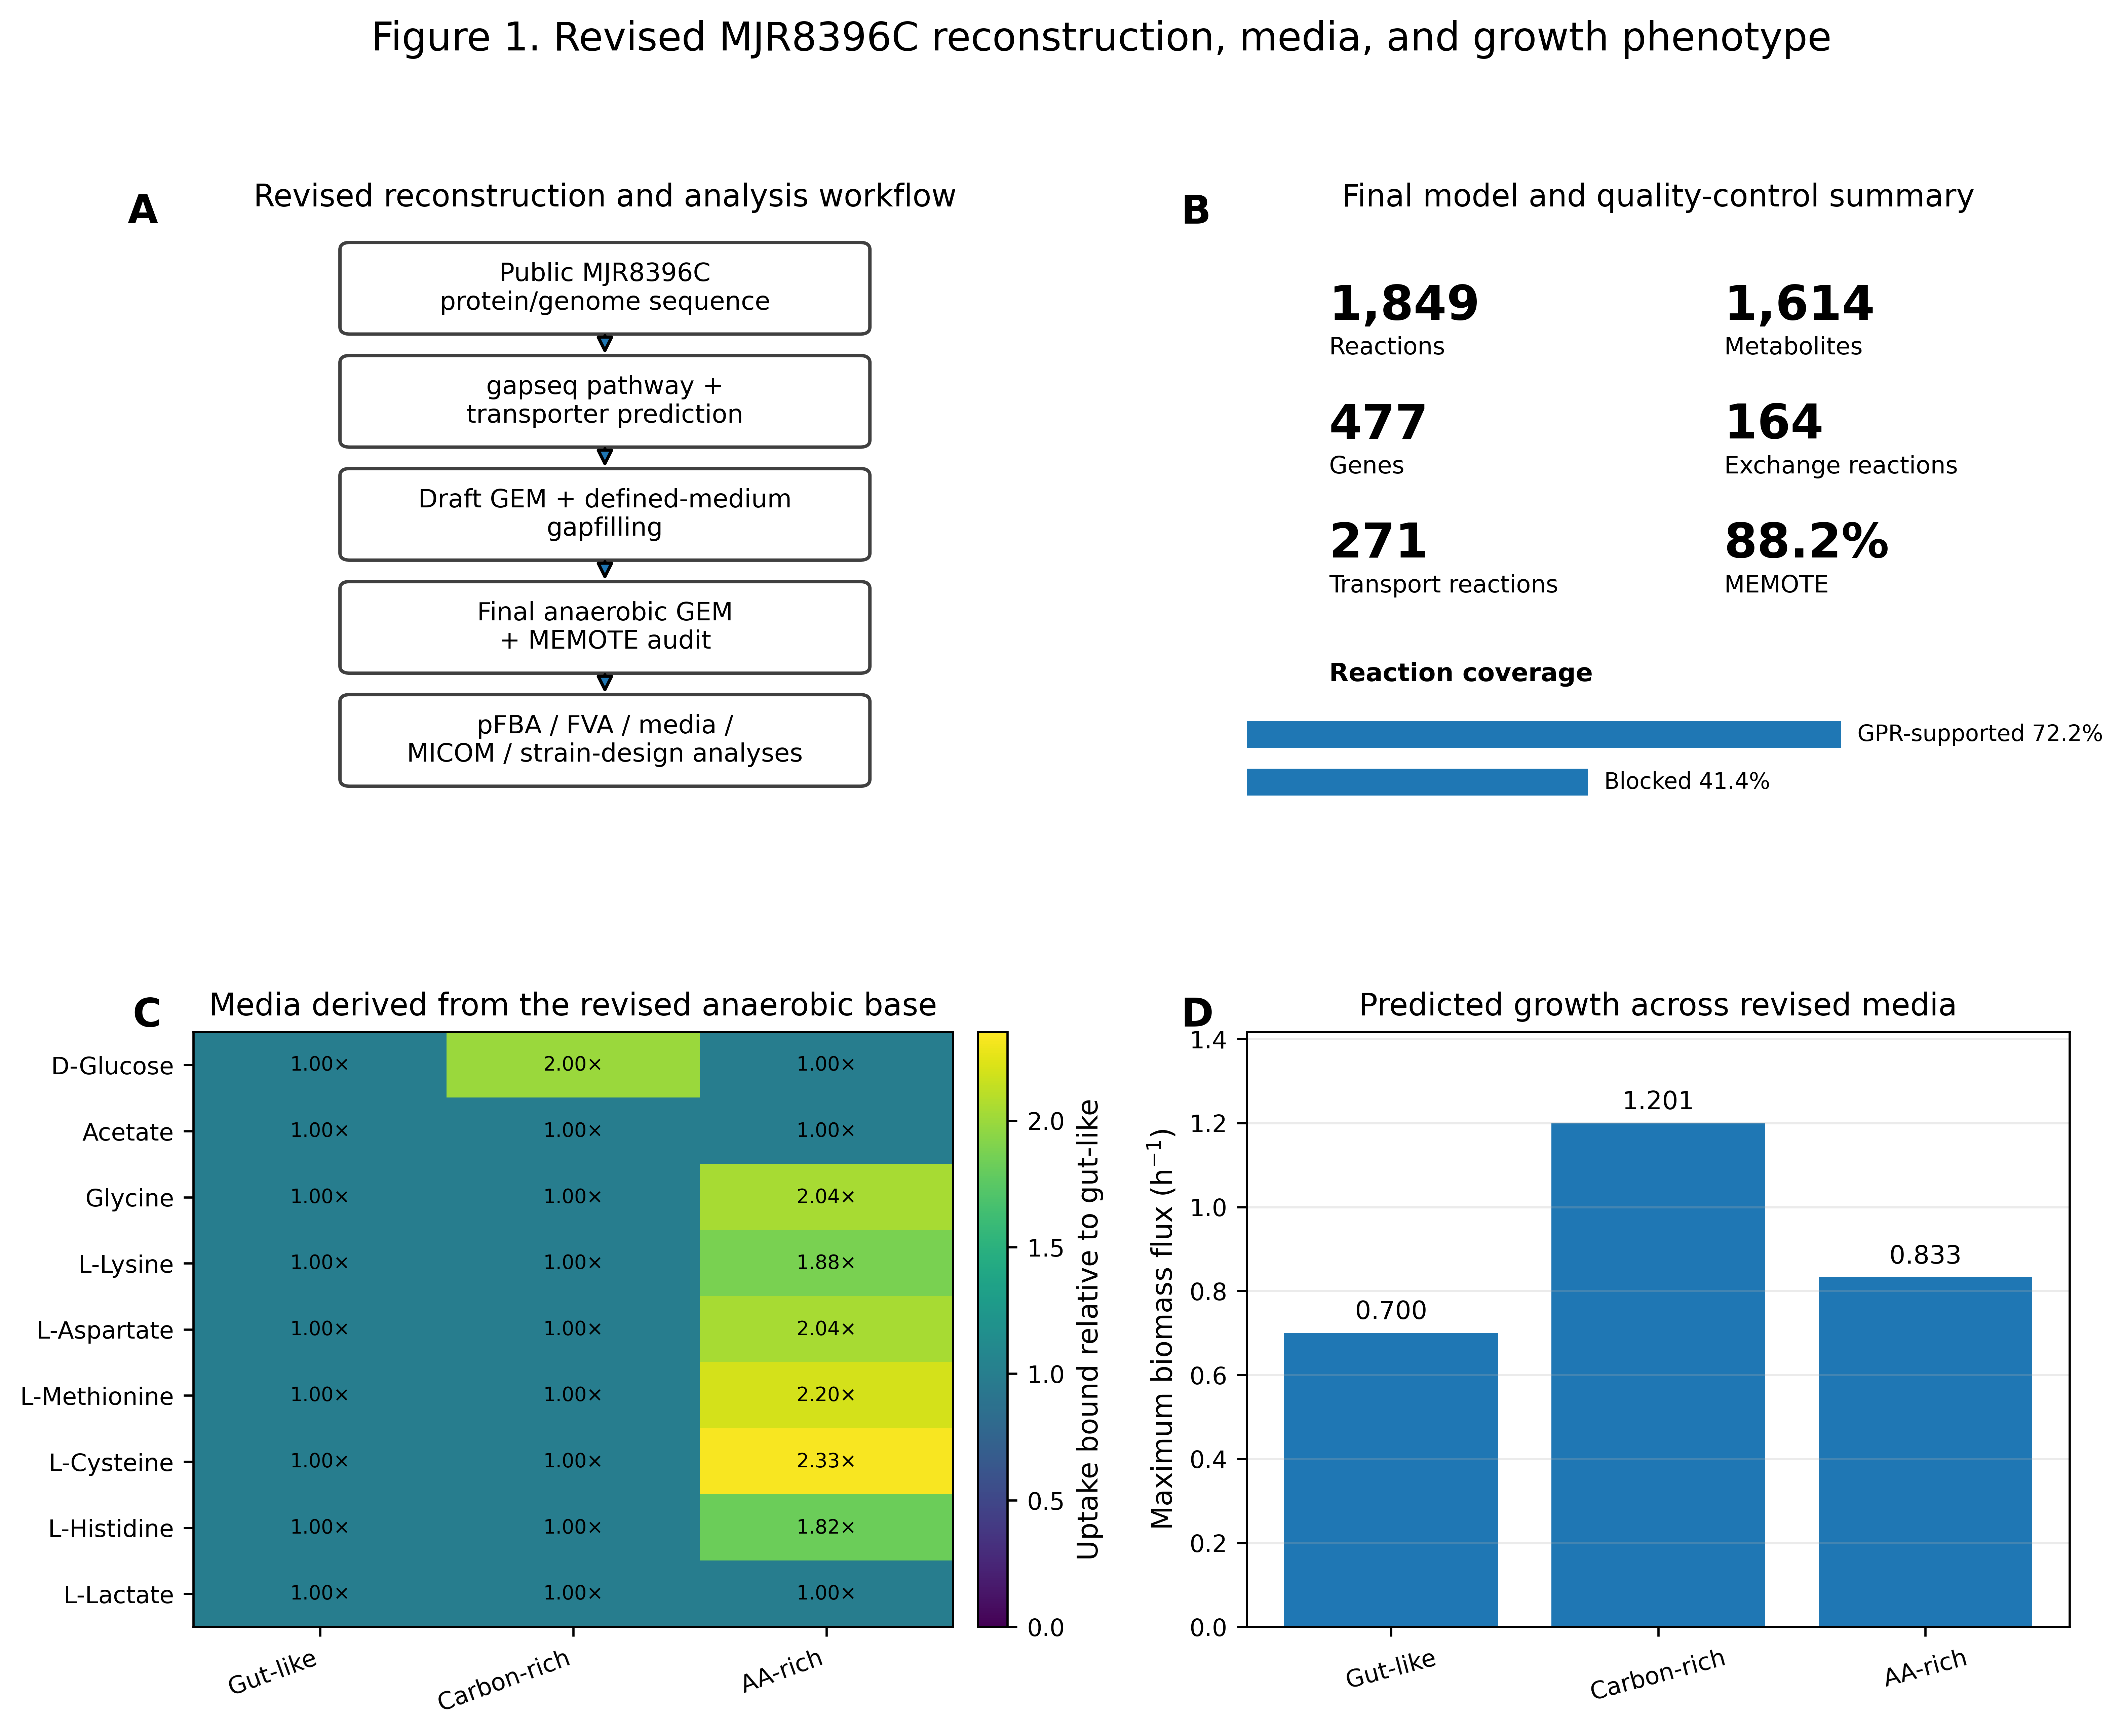

Figure_2_revised_substrate_AA_butyrate.png


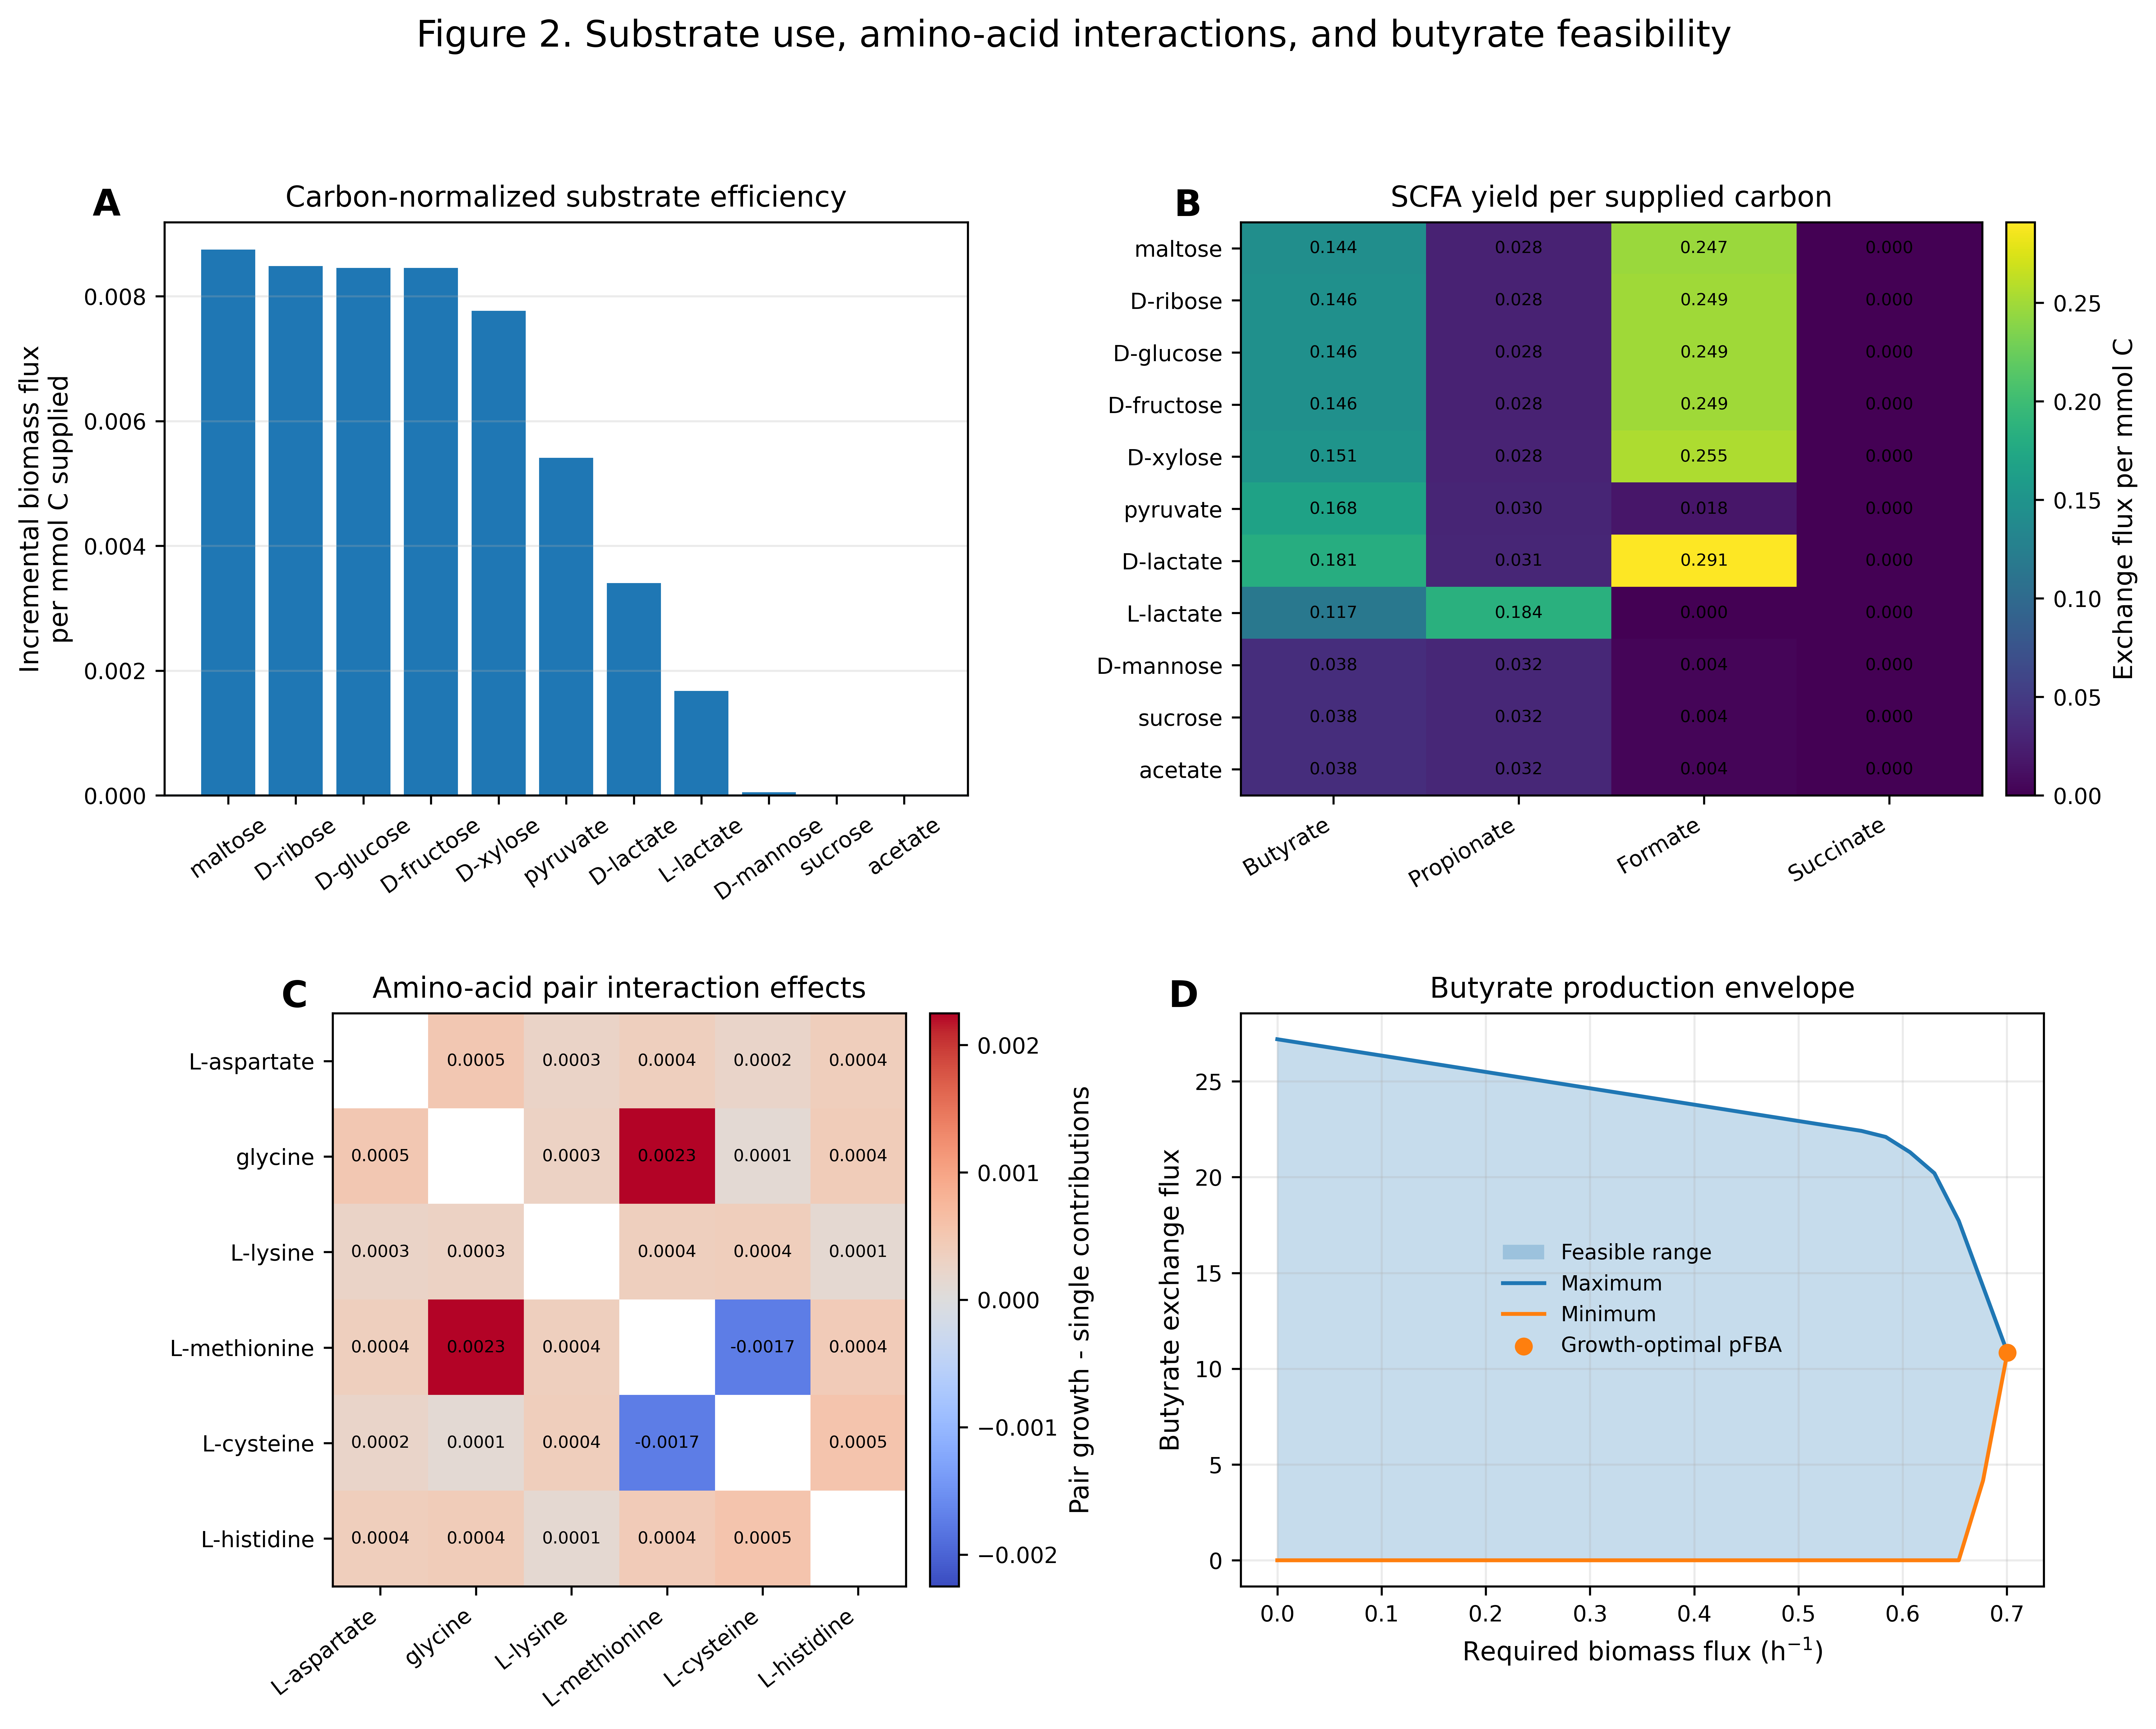

Figure_3_exploratory_strain_design.png


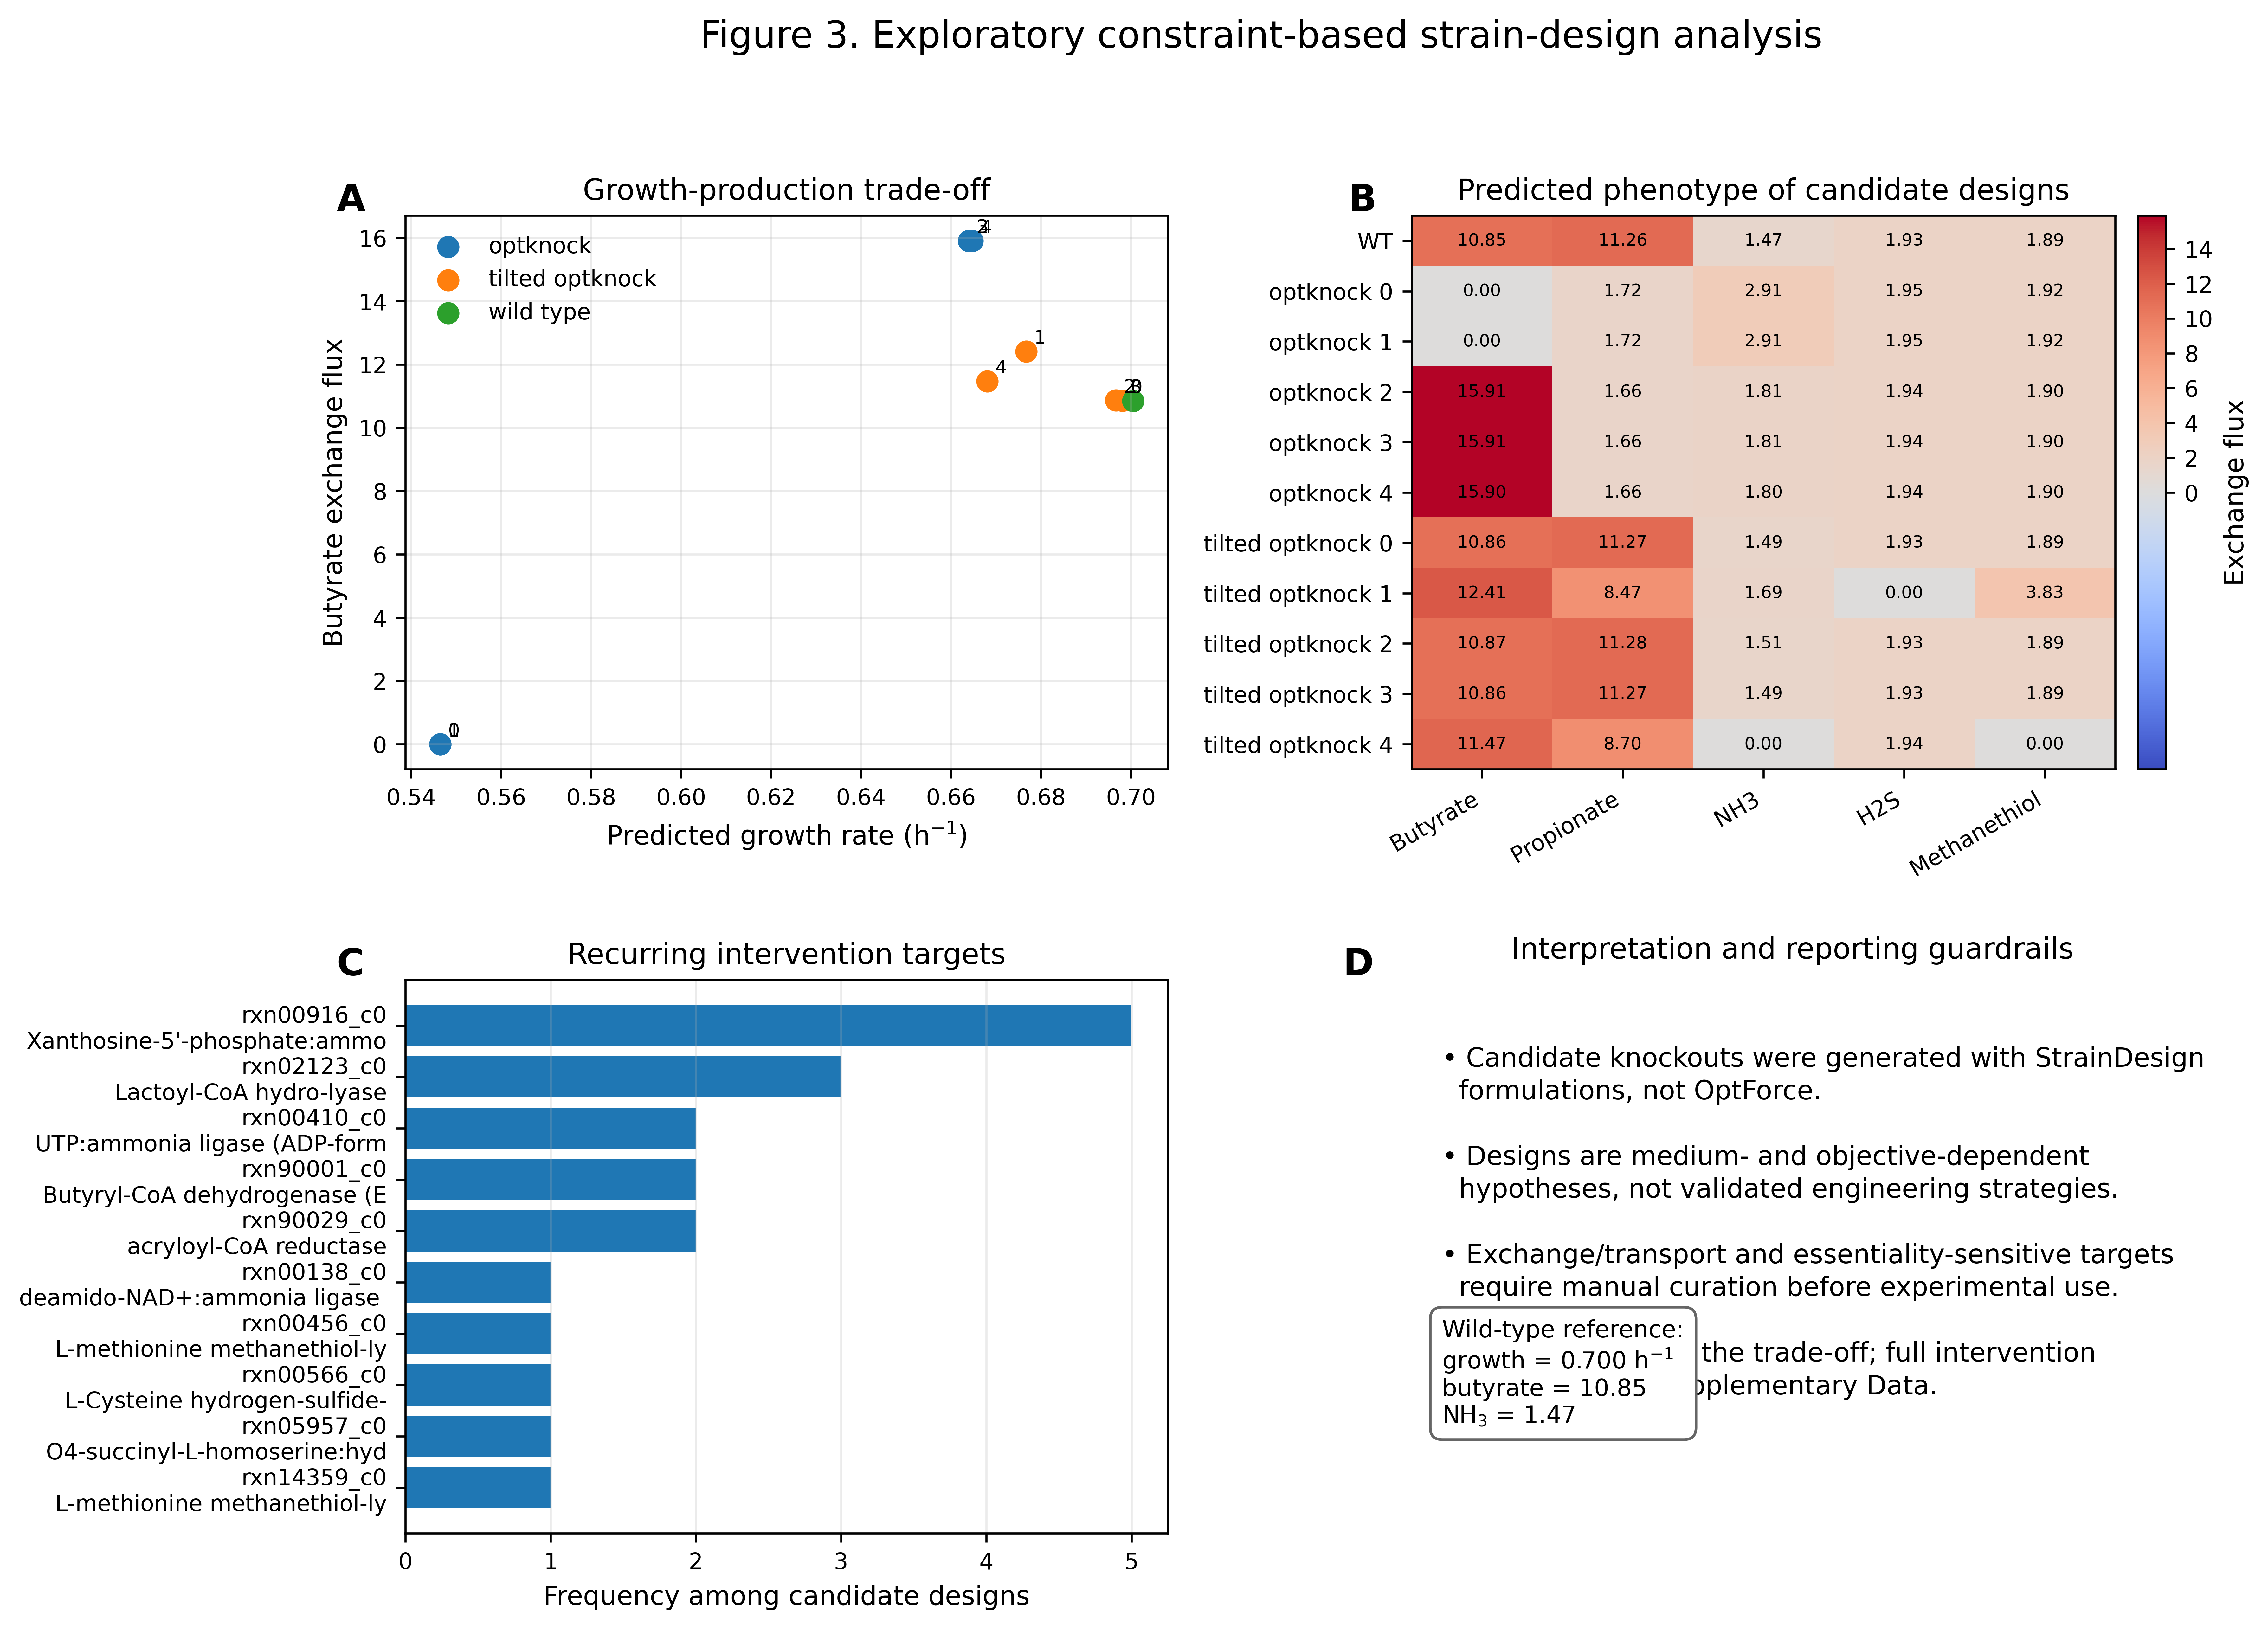

Figure_4_MICOM_community_exchange.png


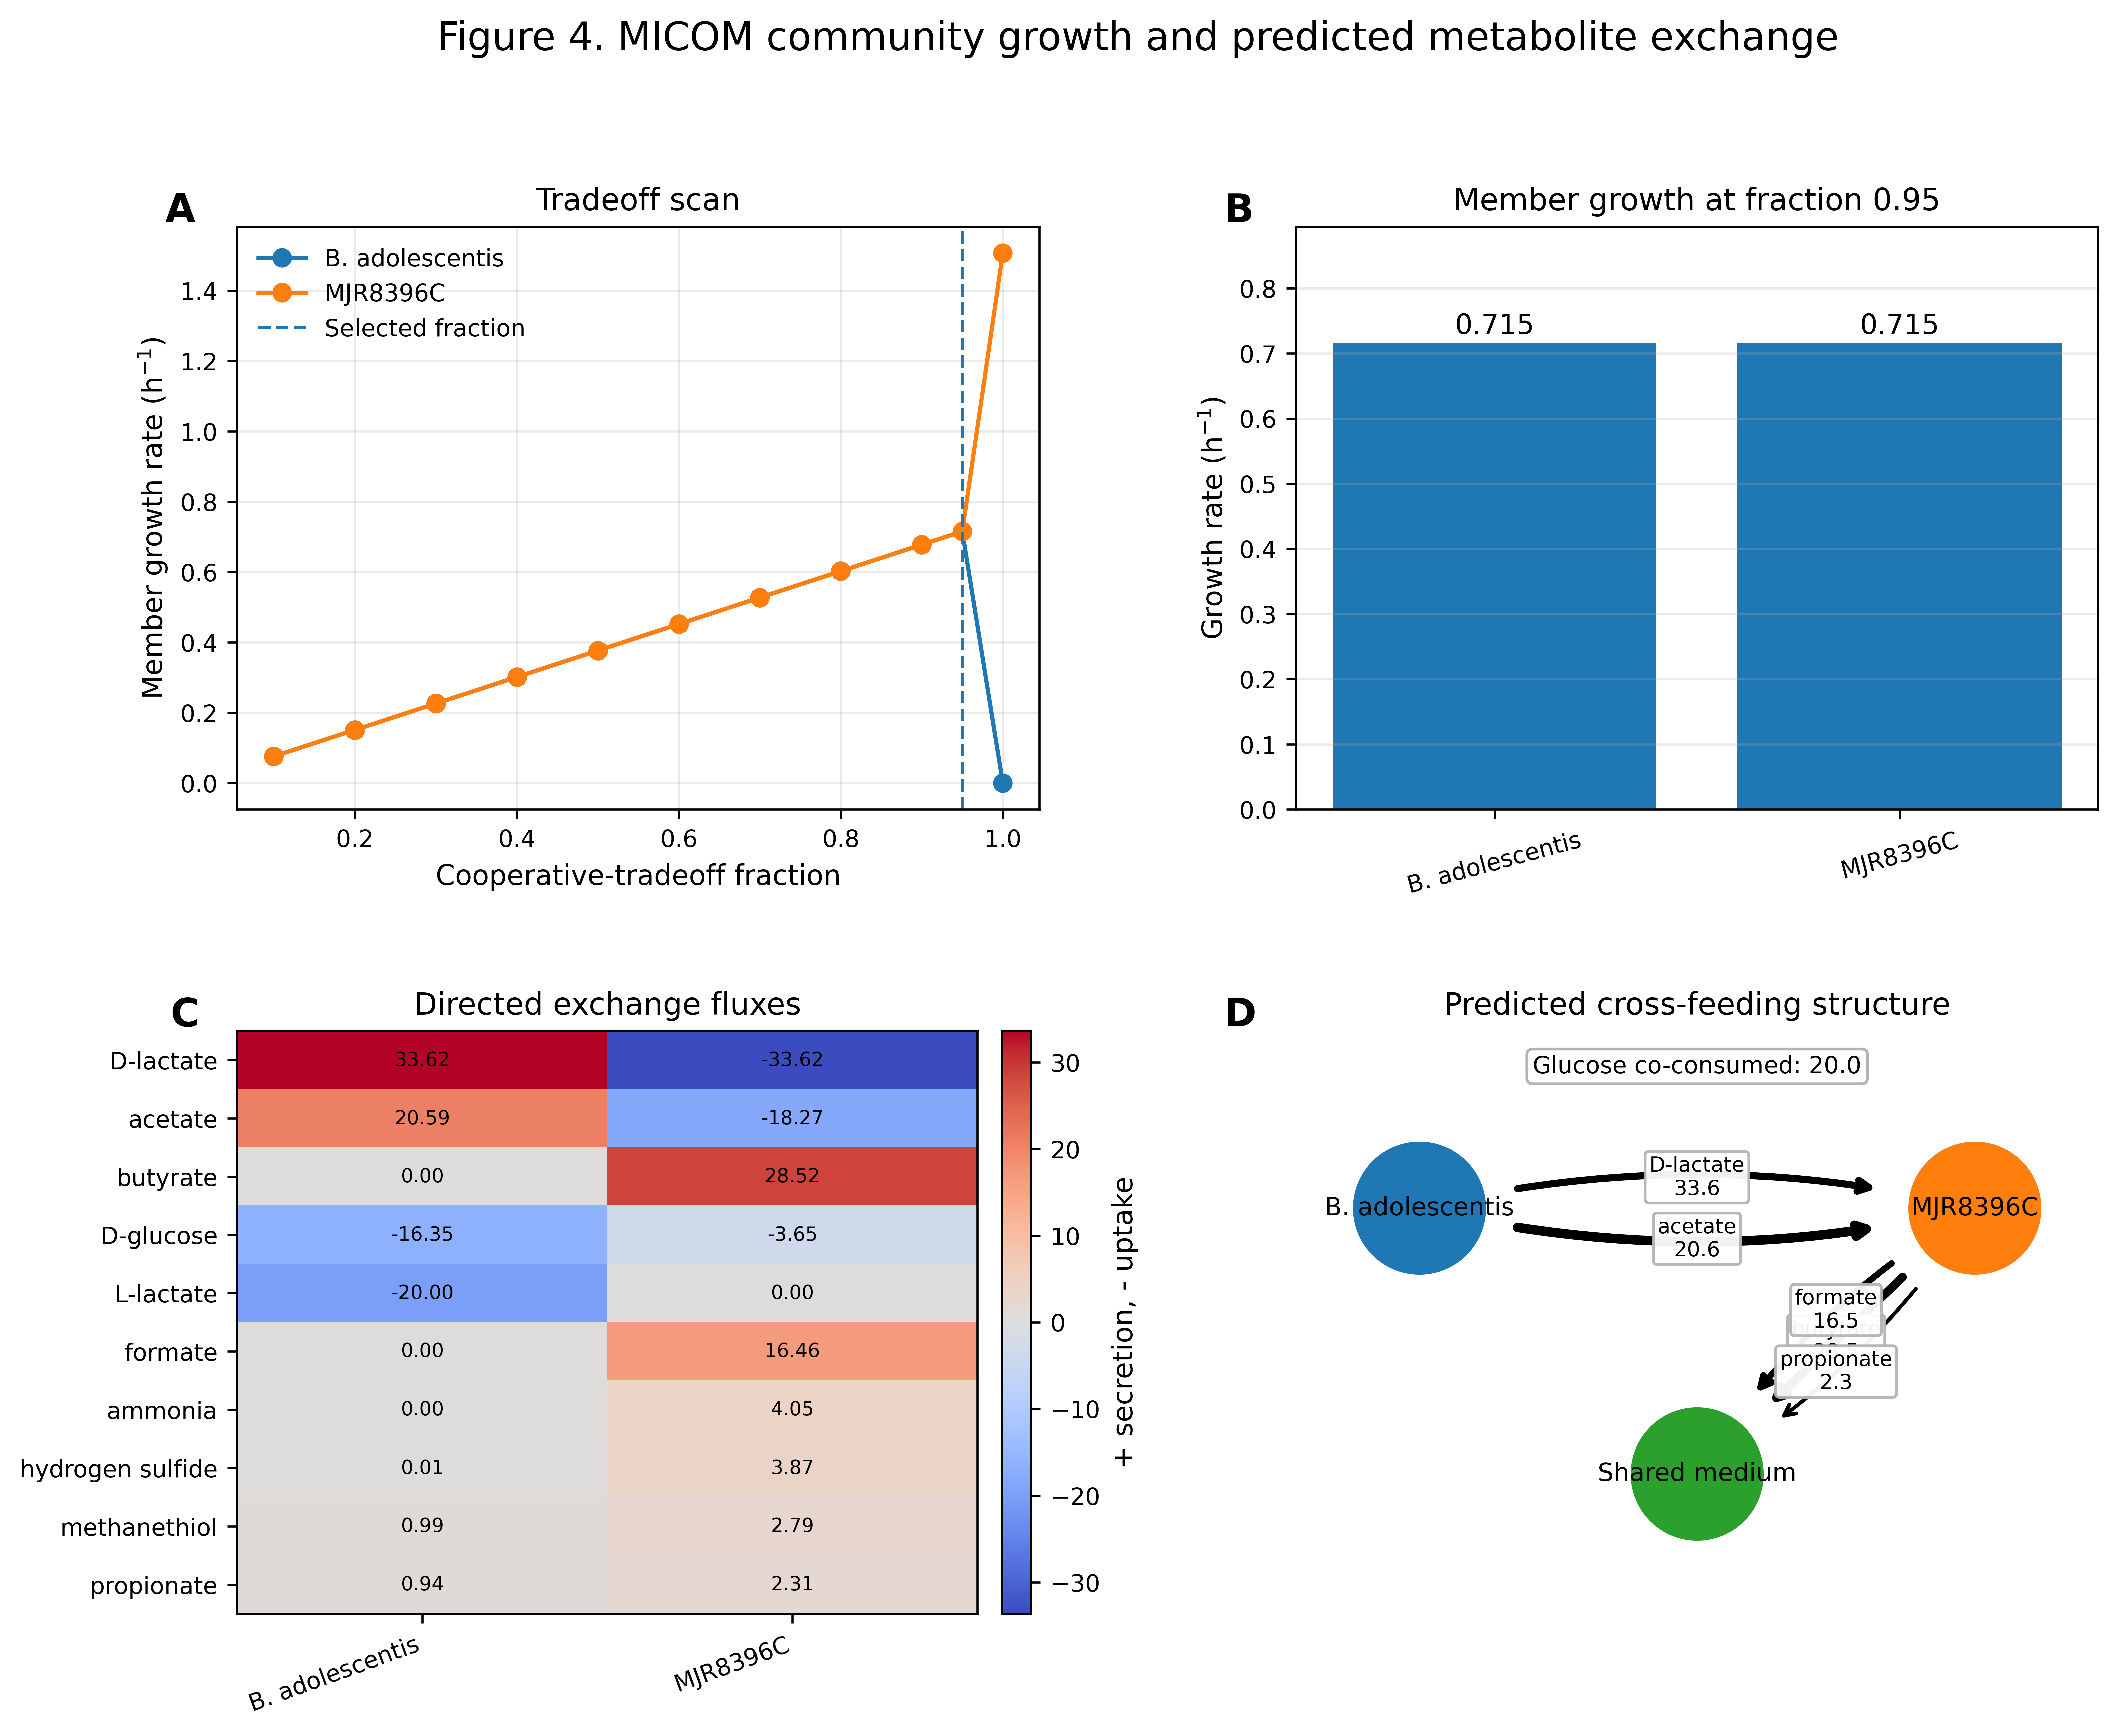

In [7]:
from IPython.display import display, Image
for name in [
    "Figure_1_revised_reconstruction_media_growth.png",
    "Figure_2_revised_substrate_AA_butyrate.png",
    "Figure_3_exploratory_strain_design.png",
    "Figure_4_MICOM_community_exchange.png",
]:
    path = PACKAGE / "figures" / name
    print(name)
    display(Image(filename=str(path), width=900))

## Interpretation guardrails

- Biomass values are model-predicted maximum biomass fluxes, not measured growth rates.
- Positive exchange flux denotes secretion; negative exchange flux denotes uptake.
- The model is a medium-gapfilled draft with 766 blocked reactions.
- Related-species studies are external benchmarks, not direct validation of MJR8396C.
- StrainDesign outputs are exploratory and must not be called OptForce unless an OptForce calculation is performed.
